In [1]:
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/mihikaajayjadhav/top-100-cryptocurrencies-daily-price-data-2025/crypto_monthly_summary.csv
/kaggle/input/datasets/mihikaajayjadhav/top-100-cryptocurrencies-daily-price-data-2025/crypto_yearly_performance.csv
/kaggle/input/datasets/mihikaajayjadhav/top-100-cryptocurrencies-daily-price-data-2025/crypto_historical_365days.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")


In [3]:
file_path = "/kaggle/input/datasets/mihikaajayjadhav/top-100-cryptocurrencies-daily-price-data-2025/crypto_historical_365days.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()


Dataset loaded successfully.
Shape: (33364, 15)


,coin_id,coin_name,symbol,market_cap_rank,timestamp,date,price,market_cap,volume,daily_return,price_ma7,price_ma30,volatility_7d,cumulative_return,month
0,aave,Aave,AAVE,46,2024-12-04 00:00:00,2024-12-04,241.886714,3.633154e+09,1.181708e+09,NaN,241.886714,241.886714,NaN,NaN,2024-12
1,aave,Aave,AAVE,46,2024-12-05 00:00:00,2024-12-05,255.966610,3.841768e+09,1.191179e+09,5.820864,248.926662,248.926662,NaN,5.820864,2024-12
2,aave,Aave,AAVE,46,2024-12-06 00:00:00,2024-12-06,248.589404,3.725870e+09,8.706666e+08,-2.882097,248.814243,248.814243,6.153922,2.771004,2024-12
3,aave,Aave,AAVE,46,2024-12-07 00:00:00,2024-12-07,281.755167,4.226339e+09,1.120551e+09,13.341583,257.049474,257.049474,8.119016,16.482283,2024-12
4,aave,Aave,AAVE,46,2024-12-08 00:00:00,2024-12-08,282.398618,4.241226e+09,6.553344e+08,0.228372,262.119303,262.119303,7.120498,16.748297,2024-12


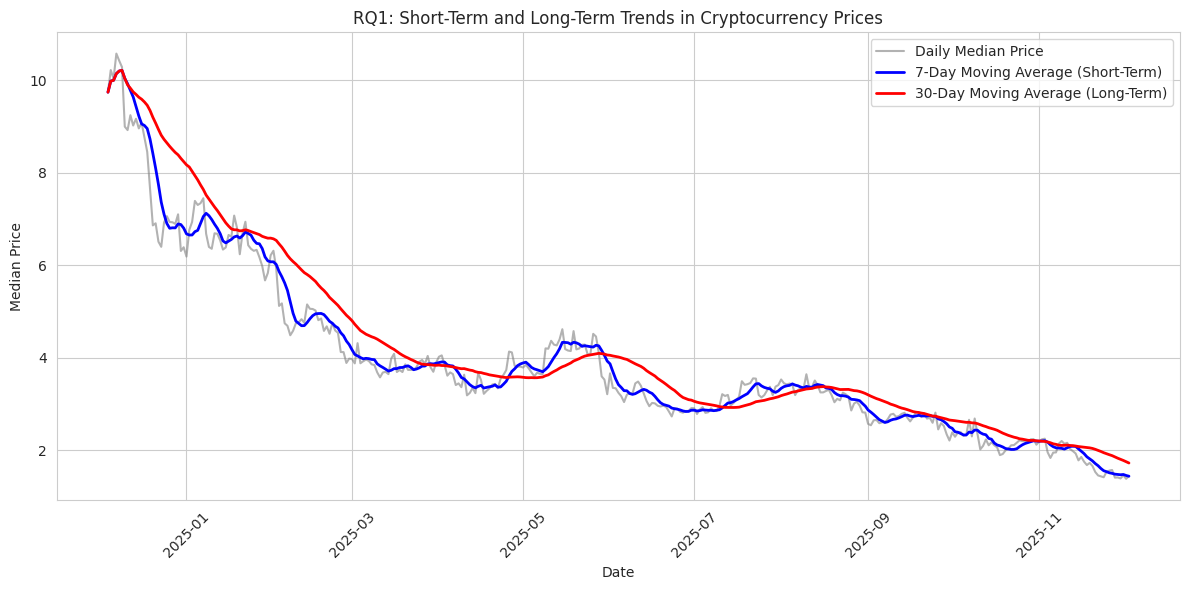

In [4]:
# RQ1: Short-term and long-term cryptocurrency price trends

import pandas as pd
import matplotlib.pyplot as plt
import os

DATA_PATH = "/kaggle/input/datasets/mihikaajayjadhav/top-100-cryptocurrencies-daily-price-data-2025/crypto_historical_365days.csv"

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.lower().str.strip()
df["date"] = pd.to_datetime(df["date"])

daily_trend = (
    df.groupby("date")
      .agg(
          mean_price=("price", "mean"),
          median_price=("price", "median")
      )
      .reset_index()
      .sort_values("date")
)

daily_trend["short_term_ma_7"] = daily_trend["median_price"].rolling(window=7, min_periods=1).mean()
daily_trend["long_term_ma_30"] = daily_trend["median_price"].rolling(window=30, min_periods=1).mean()

daily_trend.to_csv("/kaggle/working/RQ1_daily_trend.csv", index=False)

summary = daily_trend[["mean_price", "median_price", "short_term_ma_7", "long_term_ma_30"]].describe().round(4)
summary.to_csv("/kaggle/working/RQ1_summary.csv")

plt.figure(figsize=(12, 6))
plt.plot(daily_trend["date"], daily_trend["median_price"], label="Daily Median Price", color="gray", alpha=0.6)
plt.plot(daily_trend["date"], daily_trend["short_term_ma_7"], label="7-Day Moving Average (Short-Term)", color="blue", linewidth=2)
plt.plot(daily_trend["date"], daily_trend["long_term_ma_30"], label="30-Day Moving Average (Long-Term)", color="red", linewidth=2)

plt.title("RQ1: Short-Term and Long-Term Trends in Cryptocurrency Prices")
plt.xlabel("Date")
plt.ylabel("Median Price")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.savefig("/kaggle/working/RQ1_short_long_term_trends.pdf")
plt.show()
